<a href="https://colab.research.google.com/github/OCR-tech/AdaptDL/blob/main/Exercise%20Solutions/%F0%9F%9B%A0%20%2003_Computer_vision_%26_convolutional_neural_networks_in_TensorFlow_Exercise_Solution_1ok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Computer vision & convolutional neural networks in TensorFlow Exercise Solution

### Questionnaire
1. Spend 20-minutes reading and interacting with the [CNN explainer website](https://poloclub.github.io/cnn-explainer/).
  - What are the key terms? e.g. explain convolution in your own words, pooling in your own words

2. Play around with the "understanding hyperparameters" section in the [CNN explainer](https://poloclub.github.io/cnn-explainer/) website for 10-minutes.
  - What is the kernel size?
  - What is the stride?
  - How could you adjust each of these in TensorFlow code?

3. Take 10 photos of two different things and build your own CNN image classifier using the techniques we've built here.

4. Find an ideal learning rate for a simple convolutional neural network model on your the 10 class dataset.

In [5]:
# Importing the needed packages
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Spend 20-minutes reading and interacting with the [CNN explainer website](https://poloclub.github.io/cnn-explainer/).

What are the key terms? e.g. explain convolution in your own words, pooling in your own words
- A **CNN** is a neural network algorithm used to recognize patters in data


### 3. Take 10 photos of two different things and build your own CNN image classifier using the techniques we've built here.

I have my own image classifier dataset in my drive. This dataset contains 10 images of hot dog and another 10 images of random things (not a hot dog).

The goal is to train a classifier that will classify between hot dog and not dog.

Likewise feel free to use your own dataset.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Getting the data path
data_dir = 'drive/MyDrive/colab_notebooks3/CNN_dataset'
hot_dog_path = 'drive/MyDrive/colab_notebooks3/CNN_dataset/hot_dog'
not_hot_dog_path = 'drive/MyDrive/colab_notebooks3/CNN_dataset/not_hot_dog'

In [11]:
# Using ImageDataGenerators to read in images with labels
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Creating a instance of the ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1/255.,
                                   validation_split = 0.3) # creating a valid split in the train data

# Grabbing our image file from directories
train_data = train_datagen.flow_from_directory(data_dir ,
                                               batch_size = 2 ,
                                               target_size = (200 , 200),
                                               class_mode = 'binary',
                                               seed = 42 ,
                                               subset = 'training')

valid_data = train_datagen.flow_from_directory(data_dir ,
                                               batch_size = 2 ,
                                               target_size = (200 , 200) ,
                                               class_mode = 'binary' ,
                                               seed = 42 ,
                                               subset = 'validation')

Found 14 images belonging to 2 classes.
Found 6 images belonging to 2 classes.


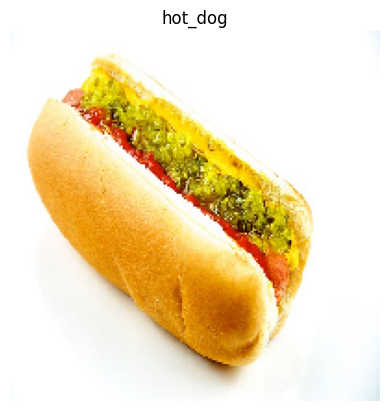

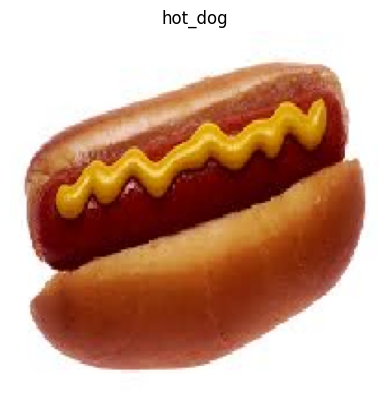

In [16]:
# Let's do a simple visualization (checking purpose)
x , y  = next(train_data)
for i in range(2):
  image = x[i]
  label = y[i]
  plt.axis(False)
  # print(label) --> for checking whether it's plotting right ones
  if label == 1.0:
    label = 'not_hot_dog'
  else:
    label = 'hot_dog'
  plt.title(label)
  plt.imshow(image)
  plt.show()

In [17]:
x.shape

(2, 200, 200, 3)

In [18]:
# Building a simple model
from tensorflow.keras import layers

model = tf.keras.Sequential([
  layers.Conv2D(filters = 2 , kernel_size = 1 ,
                activation = 'relu' ,
                input_shape = (200 , 200, 3)),

  layers.MaxPool2D(pool_size= 1 ,
                   padding = 'valid'),
   layers.Conv2D(filters = 2 , kernel_size = 1 ,
                activation = 'relu' ),
  layers.MaxPool2D(1 , padding= 'valid'),
  layers.Flatten(),
  layers.Dense(1 , activation= 'sigmoid')

])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 200, 200, 2)         │               8 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 200, 200, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 200, 200, 2)         │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 200, 200, 2)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 80000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │          80,001 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 80,015 (312.56 KB)

 Trainable params: 80,015 (312.56 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compiling the model
model.compile(loss = tf.keras.losses.BinaryCrossentropy() ,
              optimizer = tf.keras.optimizers.Adam() ,
              metrics = ['accuracy'])

# Fit the model
history = model.fit(train_data ,
                    epochs = 20 ,
                    validation_data = valid_data )

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 679ms/step - accuracy: 0.2265 - loss: 2.0049 - val_accuracy: 0.5000 - val_loss: 1.0273
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5906 - loss: 1.7131 - val_accuracy: 0.5000 - val_loss: 3.6312
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5743 - loss: 1.8782 - val_accuracy: 0.5000 - val_loss: 1.1921
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9592 - loss: 0.2712 - val_accuracy: 0.6667 - val_loss: 0.8047
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8290 - loss: 0.4250 - val_accuracy: 0.6667 - val_loss: 1.0293
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9821 - loss: 0.1745 - val_accuracy: 0.5000 - val_loss: 1.3393
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8290 - loss: 0.2835 - val_accuracy: 0.6667 - val_loss: 0.8691
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 1.0000 - loss: 0.1180 - val_accuracy: 0.6667 - val_loss: 0.7583
Epoch 9/2

### 4. Find an ideal learning rate for a simple convolutional neural network model on your the 10 class dataset.

In [20]:
# Lets import learning rate scheduler
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

In [21]:
# Again fitting the same model but with our lr scheduler

from tensorflow.keras import layers

lr_model = tf.keras.Sequential([
  layers.Conv2D(filters = 2 , kernel_size = 1 ,
                activation = 'relu' ,
                input_shape = (200 , 200, 3)),

  layers.MaxPool2D(pool_size= 1 ,
                   padding = 'valid'),
   layers.Conv2D(filters = 2 , kernel_size = 1 ,
                activation = 'relu' ),
  layers.MaxPool2D(1 , padding= 'valid'),
  layers.Flatten(),
  layers.Dense(1 , activation= 'sigmoid')

])

# Compiling the model
lr_model.compile(loss = tf.keras.losses.BinaryCrossentropy() ,
              optimizer = tf.keras.optimizers.Adam() ,
              metrics = ['accuracy'])

# Fit the model
lr_history = lr_model.fit(train_data ,
                    epochs = 10 ,
                    validation_data = valid_data  ,
                    callbacks = [lr_scheduler])

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.4207 - loss: 0.6873 - val_accuracy: 0.6667 - val_loss: 0.6772 - learning_rate: 1.0000e-04
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7726 - loss: 0.6688 - val_accuracy: 0.6667 - val_loss: 0.6649 - learning_rate: 1.1220e-04
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.7899 - loss: 0.6256 - val_accuracy: 0.5000 - val_loss: 0.6629 - learning_rate: 1.2589e-04
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.6121 - loss: 0.6460 - val_accuracy: 0.6667 - val_loss: 0.6389 - learning_rate: 1.4125e-04
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9821 - loss: 0.5753 - val_accuracy: 0.6667 - val_loss: 0.6260 - learning_rate: 1.5849e-04
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9717 - loss: 0.5347 - val_accuracy: 0.6667 - val_loss: 0.6160 - learning_rate: 1.7783e-04
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9436 - loss: 0.5952

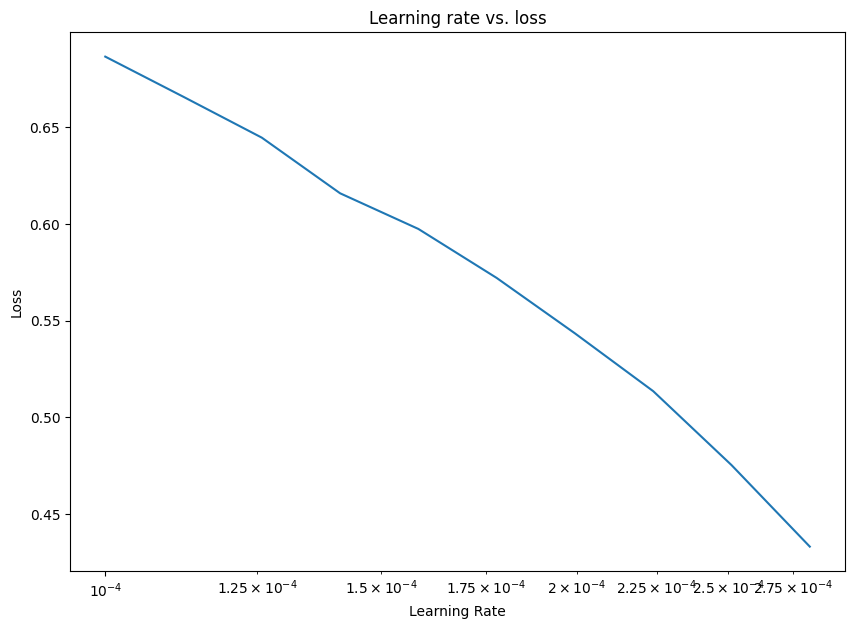

In [23]:
# Plot the learning rate versus the loss (to figure out where is the inflection point)
lrs = 1e-4 * (10 ** (np.arange(10)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, lr_history.history["loss"]) # we want the x-axis (learning rate) to be log scale
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

In [24]:
# Our learning rate from the graph above
lr = 2 * 1e-4
lr

0.0002

In [25]:
# Again fitting the same model but with our lr scheduler

from tensorflow.keras import layers

lr_model = tf.keras.Sequential([
  layers.Conv2D(filters = 2 , kernel_size = 1 ,
                activation = 'relu' ,
                input_shape = (200 , 200, 3)),

  layers.MaxPool2D(pool_size= 1 ,
                   padding = 'valid'),
   layers.Conv2D(filters = 2 , kernel_size = 1 ,
                activation = 'relu' ),
  layers.MaxPool2D(1 , padding= 'valid'),
  layers.Flatten(),
  layers.Dense(1 , activation= 'sigmoid')

])

# Compiling the model
lr_model.compile(loss = tf.keras.losses.BinaryCrossentropy() ,
              optimizer = tf.keras.optimizers.Adam(learning_rate = lr) ,
              metrics = ['accuracy'])

# Fit the model
lr_history = lr_model.fit(train_data ,
                    epochs = 10 ,
                    validation_data = valid_data)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.6219 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.3573 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.6427 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5021 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.6302 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.4740 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.4490 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5083 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931


Wow! We cann see that our model has improved a bit. Tweaking the learning rate is really important. And remember we trained our model with only few samples (10 pics) try training your model with more data and the results will be better than this.